### A notebook to give a demo on representation learning and embeddings

Designed by: [Tirtharaj Dash](https://tirtharajdash.github.io)

You will install requirements if needed:
```bash
pip install gensim sentence-transformers scikit-learn seaborn
```

In [9]:
#core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
SEED = 42
np.random.seed(SEED)
print("All imports OK")

All imports OK


#### Word embeddings

We will build a small hand-crafted corpus spanning four semantic domains:

**Animals**, **Countries**, **Chemistry/molecules**, and **Machine learning**.

Each sentence places related words in similar contexts so that Word2Vec
learns semantically meaningful embeddings even on this tiny corpus.

In [17]:
corpus_raw = [
    # Animals
    "the cat sat on the mat and the dog ran in the garden",
    "the dog barked at the cat sitting near the fence",
    "lions and tigers are large wild cats that hunt prey",
    "the wolf howled at the moon while the fox watched quietly",
    "birds like eagles and hawks soar high above the mountains",
    "dolphins and whales are marine mammals that swim in oceans",
    "the horse galloped across the field and the cow grazed nearby",
    "rabbits and squirrels eat nuts and vegetables in the forest",
    "I wonder whether dolphins and birds have the same set of proteins",
    "there are a lot of stray dogs in university campuses in India",
    # Countries and capitals
    "france is a country in europe and paris is its capital city",
    "germany is a country in europe and berlin is its capital city",
    "japan is a country in asia and tokyo is its capital city",
    "india is a country in asia and delhi is its capital city",
    "brazil is a country in south america and brasilia is its capital",
    "australia is a country and canberra is its capital city",
    "canada is a country in north america and ottawa is its capital",
    "china is a large country in asia and beijing is its capital",
    # Chemistry / molecules
    "glucose is a simple sugar molecule used for energy in cells",
    "proteins are large molecules made of amino acid chains",
    "dna is a molecule that encodes genetic information in cells",
    "enzymes are proteins that catalyse chemical reactions in cells",
    "atp is a molecule that stores and transfers energy in cells",
    "lipids are molecules that form the membrane of biological cells",
    "caffeine is a molecule found in coffee tea and many beverages",
    "aspirin is a common drug molecule used to reduce pain and fever",
    "proteins are made of sequences of amino acids",
    # Machine learning
    "neural networks learn representations from large amounts of data",
    "deep learning models are trained using gradient descent algorithms",
    "transformers use attention to model relationships between tokens",
    "embeddings map discrete tokens to continuous vector representations",
    "backpropagation computes gradients through layers of a neural network",
    "convolutional networks learn local features from image data efficiently",
    "recurrent networks process sequential data using hidden state vectors",
    "training requires a loss function and an optimisation algorithm",
    "convolutional networks are often taught with examples of cat and dog image classification"
]

corpus = [s.lower().split() for s in corpus_raw]
print(f"Corpus : {len(corpus)} sentences")
print(f"Example: {corpus[0]}")

Corpus : 36 sentences
Example: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'the', 'dog', 'ran', 'in', 'the', 'garden']


We will train a skip-gram Word2Vec model on the corpus.

**Objective**: given centre word $w$, predict context words within window $c$:
$$p(o \mid w) = \frac{\exp(\mathbf{u}_o^\top \mathbf{v}_w)}{\sum_{j \in V} \exp(\mathbf{u}_j^\top \mathbf{v}_w)}$$

In practice, **negative sampling** replaces the full softmax with a binary objective — push up the score for real context words, push down scores for randomly sampled noise words.


In [18]:
model = Word2Vec(
    sentences=corpus,
    vector_size=50,    # embedding dimension
    window=4,          # context window size
    min_count=1,       # include all words
    sg=1,              # skip-gram (sg=0 -> CBOW)
    negative=5,        # negative samples per positive
    epochs=500,
    seed=SEED,
    workers=1,
)

print(f"Vocabulary size : {len(model.wv)}")
print(f"Embedding dim   : {model.wv.vector_size}")
print()
print("Top-5 similar to 'cat'    :", model.wv.most_similar("cat",     topn=5))
print("Top-5 similar to 'glucose':", model.wv.most_similar("glucose", topn=5))
print("Top-5 similar to 'paris'  :", model.wv.most_similar("paris",   topn=5))

Vocabulary size : 198
Embedding dim   : 50

Top-5 similar to 'cat'    : [('dog', 0.9653851389884949), ('barked', 0.9043733477592468), ('classification', 0.9015588760375977), ('sitting', 0.8750690221786499), ('fence', 0.8658608794212341)]
Top-5 similar to 'glucose': [('simple', 0.9916976690292358), ('sugar', 0.9778918623924255), ('for', 0.9282535314559937), ('used', 0.867073118686676), ('energy', 0.8295458555221558)]
Top-5 similar to 'paris'  : [('berlin', 0.9896164536476135), ('france', 0.9761015772819519), ('europe', 0.9716061949729919), ('germany', 0.9714142084121704), ('city', 0.9513630867004395)]


Let's visualise the word embeddings in t-SNE space:

**t-SNE** maps $d$-dimensional embeddings to 2D by preserving local neighbourhood structure.

- High-dimensional similarities: modelled with a **Gaussian** kernel.
- Low-dimensional similarities: modelled with a **Student-$t$** kernel (heavy tail, prevents crowding).
- Objective: minimise $\mathrm{KL}(P \| Q)$ between the two similarity distributions.

Words from the same semantic category should cluster together.

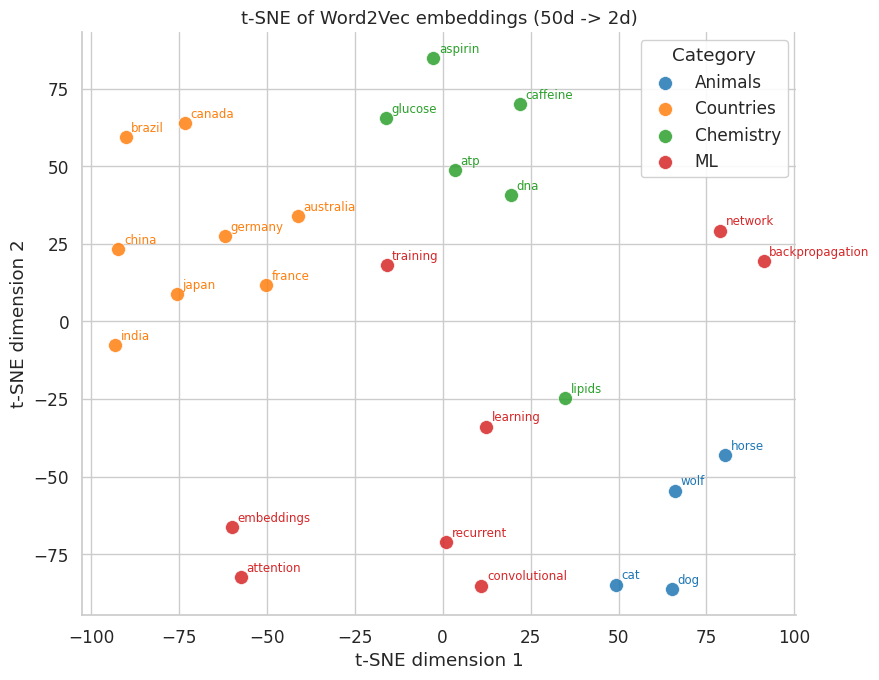

In [19]:
categories = {
    "Animals"   : ["cat", "dog", "lion", "wolf", "eagle", "dolphin", "horse", "rabbit"],
    "Countries" : ["france", "germany", "japan", "india", "brazil", "australia", "canada", "china"],
    "Chemistry" : ["glucose", "protein", "dna", "enzyme", "atp", "lipids", "caffeine", "aspirin"],
    "ML"        : ["network", "learning", "attention", "embeddings",
                   "backpropagation", "convolutional", "recurrent", "training"],
}

words, labels = [], []
for cat, word_list in categories.items():
    for w in word_list:
        if w in model.wv:
            words.append(w)
            labels.append(cat)

X = np.array([model.wv[w] for w in words])

tsne = TSNE(n_components=2, perplexity=min(10, len(words)//3),
            random_state=SEED, max_iter=2000, init="pca")
X_2d = tsne.fit_transform(X)

palette = sns.color_palette("tab10", n_colors=len(categories))
cat_color = {cat: palette[i] for i, cat in enumerate(categories)}

fig, ax = plt.subplots(figsize=(9, 7))
for cat in categories:
    idx = [i for i, l in enumerate(labels) if l == cat]
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               label=cat, color=cat_color[cat],
               s=100, alpha=0.85, edgecolors="white", linewidths=0.5)
    for i in idx:
        ax.annotate(words[i], (X_2d[i, 0], X_2d[i, 1]),
                    fontsize=8.5, xytext=(4, 4), textcoords="offset points",
                    color=cat_color[cat])

ax.set_title("t-SNE of Word2Vec embeddings (50d -> 2d)", fontsize=13)
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(title="Category", framealpha=0.9)
sns.despine()
plt.tight_layout()
#plt.savefig("tsne_words.png", dpi=120, bbox_inches="tight")
plt.show()

How similar are two embeddings? We will use cosine similarity for this.

Cosine similarity between two embeddings:
$$\cos(\mathbf{v}_i, \mathbf{v}_j) = \frac{\mathbf{v}_i \cdot \mathbf{v}_j}{\|\mathbf{v}_i\| \|\mathbf{v}_j\|}$$

Words within the same category should have high similarity (red); words across categories should have low similarity (blue).

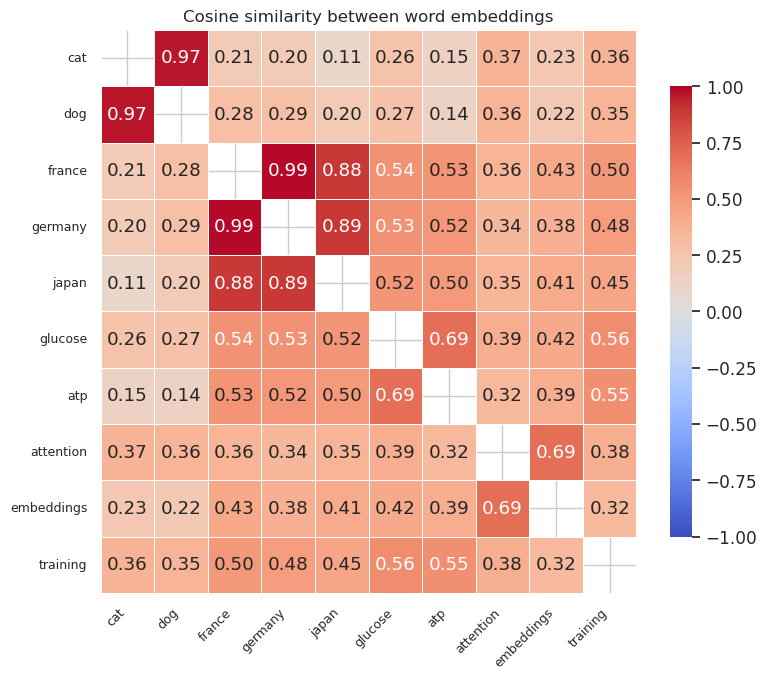

In [20]:
selected = [
    "cat",    "dog",    "eagle",
    "france", "germany","japan",
    "glucose","protein","atp",
    "attention","embeddings","training",
]
selected = [w for w in selected if w in model.wv]

vecs = normalize(np.array([model.wv[w] for w in selected]))
sim_matrix = vecs @ vecs.T

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    sim_matrix,
    xticklabels=selected, yticklabels=selected,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=0.4,
    mask=np.eye(len(selected), dtype=bool),
    ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Cosine similarity between word embeddings", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
#plt.savefig("cosine_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

#### Sentence embeddings

Let's now visualise sentence embeddings. Word embeddings represent individual tokens. For retrieval and RAG we need **sentence-level** embeddings, as we discussed in the past lectures.

We use `all-MiniLM-L6-v2` from `sentence-transformers` - a small (22M parameter) model fine-tuned with a contrastive objective on sentence pairs. It produces 384-dimensional embeddings where cosine similarity is a reliable semantic signal.

Sentences span four topics relevant to this course:
**Drug discovery**, **Deep learning**, **Transformers**, and **RAG**.

We will again use t-SNE by applying it to the 384-dimensional sentence embeddings.
We would expect that the same topic sentences should cluster together?

In [25]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("all-MiniLM-L6-v2")

sentences = {
    "Drug discovery" : [
        "Aspirin inhibits the COX enzyme and reduces inflammation.",
        "The molecule binds to the active site of the target protein.",
        "Virtual screening identifies candidate drug molecules from a library.",
        "ADMET properties determine how a drug is absorbed and metabolised.",
        "Graph neural networks predict molecular bioactivity from SMILES strings.",
    ],
    "Deep learning" : [
        "Backpropagation computes gradients by applying the chain rule.",
        "Dropout randomly zeroes units during training to prevent overfitting.",
        "Batch normalisation stabilises training by normalising activations.",
        "The attention mechanism computes a weighted sum of value vectors.",
        "Residual connections allow gradients to bypass layers directly.",
        "There are a lot of work on building graph neural networks that studies protein molecule interaction"
    ],
    "Transformers" : [
        "Multi-head attention projects queries keys and values into subspaces.",
        "Positional encoding injects order information into token embeddings.",
        "The encoder processes the source sequence with bidirectional attention.",
        "The decoder attends to encoder output via cross-attention.",
        "BERT is pretrained with masked language modelling on large corpora.",
    ],
    "RAG" : [
        "Retrieval-augmented generation retrieves documents before generating.",
        "Dense retrieval uses cosine similarity between query and document embeddings.",
        "FAISS indexes embeddings for fast approximate nearest-neighbour search.",
        "The generator conditions on retrieved context to answer the query.",
        "Embedding quality directly determines retrieval and generation quality.",
    ],
}

all_sentences, all_labels = [], []
for topic, sents in sentences.items():
    all_sentences.extend(sents)
    all_labels.extend([topic] * len(sents))

embeddings = encoder.encode(all_sentences, show_progress_bar=False)
print(f"Encoded {len(all_sentences)} sentences")
print(f"Embedding shape: {embeddings.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoded 21 sentences
Embedding shape: (21, 384)


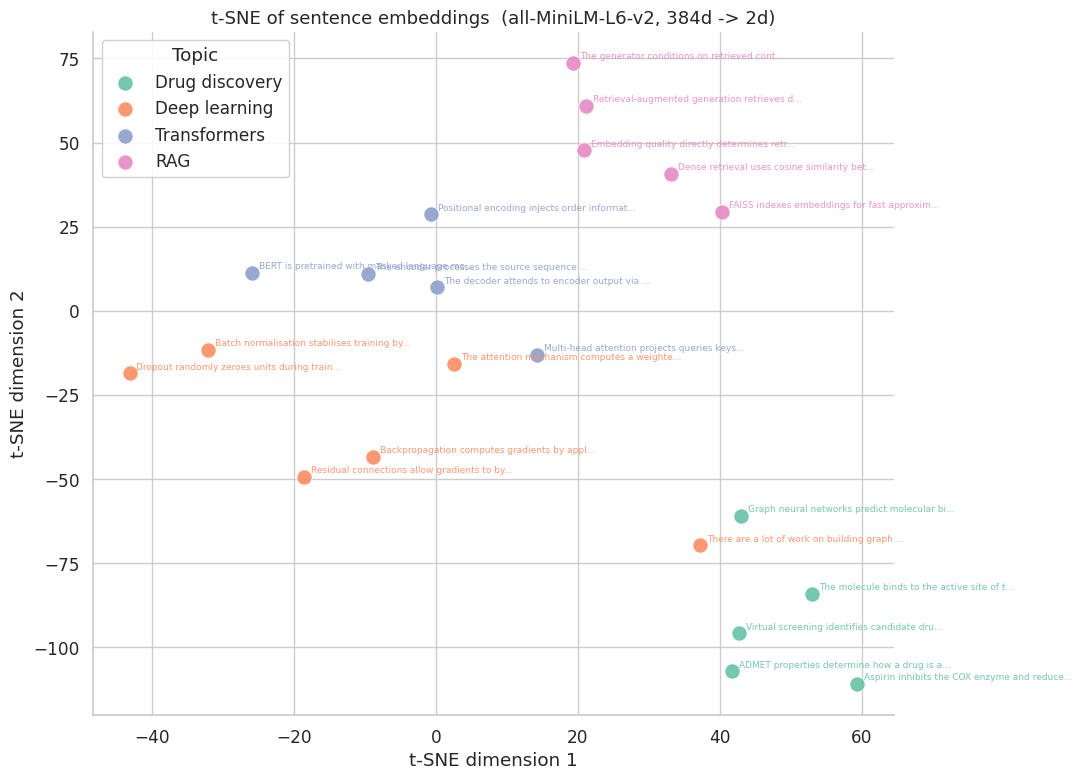

In [26]:
tsne_s = TSNE(n_components=2, perplexity=5, random_state=SEED,
              max_iter=2000, init="pca")
S_2d = tsne_s.fit_transform(embeddings)

palette_s = sns.color_palette("Set2", n_colors=len(sentences))
topic_color = {t: palette_s[i] for i, t in enumerate(sentences.keys())}

fig, ax = plt.subplots(figsize=(11, 8))
for topic in sentences:
    idx = [i for i, l in enumerate(all_labels) if l == topic]
    ax.scatter(S_2d[idx, 0], S_2d[idx, 1],
               label=topic, color=topic_color[topic],
               s=120, alpha=0.9, edgecolors="white", linewidths=0.6)
    for i in idx:
        short = all_sentences[i][:42] + "..." if len(all_sentences[i]) > 42 else all_sentences[i]
        ax.annotate(short, (S_2d[i, 0], S_2d[i, 1]),
                    fontsize=6.5, xytext=(5, 3), textcoords="offset points",
                    color=topic_color[topic], alpha=0.9)

ax.set_title("t-SNE of sentence embeddings  (all-MiniLM-L6-v2, 384d -> 2d)", fontsize=13)
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(title="Topic", framealpha=0.9)
sns.despine()
plt.tight_layout()
#plt.savefig("tsne_sentences.png", dpi=120, bbox_inches="tight")
plt.show()

Now, that we have built a sentence encoder, we can check how good our retrieval can be, given a query sentence.

Given a query, rank all sentences by **cosine similarity** to the query embedding.
This is exactly what the retrieval step in RAG does.

$$\mathrm{score}(q, d) = \cos(\mathbf{z}_q, \mathbf{z}_d) = \frac{\mathbf{z}_q \cdot \mathbf{z}_d}{\|\mathbf{z}_q\| \|\mathbf{z}_d\|}$$

A semantically relevant document should score high even with no keyword overlap.

Query: How does a small molecule interact with a protein target?
-----------------------------------------------------------------
  [1] (Drug discovery   ) score=0.794  |  The molecule binds to the active site of the target protein.
  [2] (Deep learning    ) score=0.475  |  There are a lot of work on building graph neural networks that studies protein molecule interaction
  [3] (Drug discovery   ) score=0.364  |  Virtual screening identifies candidate drug molecules from a library.
  [4] (Drug discovery   ) score=0.266  |  ADMET properties determine how a drug is absorbed and metabolised.
  [5] (Drug discovery   ) score=0.262  |  Graph neural networks predict molecular bioactivity from SMILES strings.


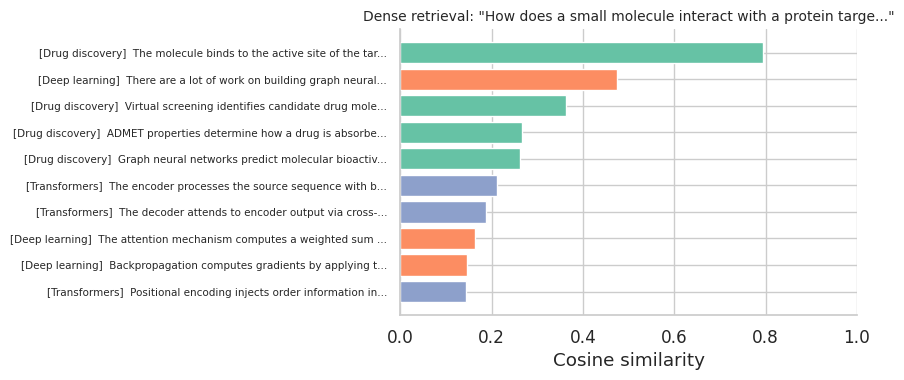

In [27]:
query = "How does a small molecule interact with a protein target?"
q_emb = encoder.encode([query])

# Cosine similarities
norm_emb = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9)
norm_q   = q_emb      / (np.linalg.norm(q_emb)                             + 1e-9)
sims     = (norm_emb @ norm_q.T).squeeze()

top_idx  = sims.argsort()[::-1][:5]
print(f"Query: {query}")
print("-" * 65)
for rank, i in enumerate(top_idx, 1):
    print(f"  [{rank}] ({all_labels[i]:<17}) score={sims[i]:.3f}  |  {all_sentences[i]}")

top10 = sims.argsort()[::-1][:10]
bar_colors = [topic_color[all_labels[i]] for i in top10]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(10), sims[top10][::-1], color=bar_colors[::-1], edgecolor="white")
ax.set_yticks(range(10))
labels_plot = [f"[{all_labels[i]}]  {all_sentences[i][:48]}..."
               for i in top10[::-1]]
ax.set_yticklabels(labels_plot, fontsize=7.5)
ax.set_xlabel("Cosine similarity")
ax.set_title(f'Dense retrieval: "{query[:55]}..."', fontsize=10)
ax.set_xlim(0, 1)
sns.despine()
plt.tight_layout()
#plt.savefig("retrieval.png", dpi=120, bbox_inches="tight")
plt.show()

## Exercises

1. Add few (maybe 10, 20) more sentences to one of the four topics in the corpus and retrain Word2Vec. Does the t-SNE cluster tighten?
2. Change `perplexity` in t-SNE from 5 to 15 to 30. How does the visualisation change? What does this tell you about t-SNE's sensitivity?
3. Try a different query in the dense retrieval cell. Does the model retrieve semantically relevant sentences even when there is no keyword overlap with the query?
4. Replace `all-MiniLM-L6-v2` with `all-mpnet-base-v2` (larger model). Do the t-SNE clusters become tighter?
5. Compute the cosine similarity between two sentences you expect to be similar and two you expect to be dissimilar. Do the scores match your expectation?
6. What happens to the cosine similarity heatmap if you use raw BERT embeddings (`bert-base-uncased`, mean pooling) instead of a contrastive-trained model?